In [2]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv('retail_price.csv')
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [4]:
# Convert date
df['month_year'] = pd.to_datetime(df['month_year'], format='%d-%m-%Y')

# Sort
df = df.sort_values(['product_id', 'month_year'])

# Target
df['qty'] = df['qty'].fillna(0)

In [5]:
def create_features(df):
    df = df.copy()
    
    # Lag features
    for lag in [1, 2, 3]:
        df[f'lag_{lag}'] = df.groupby('product_id')['qty'].shift(lag)
    
    # Rolling stats
    df['rolling_mean_3'] = df.groupby('product_id')['qty'].shift(1).rolling(3).mean()
    df['rolling_std_3'] = df.groupby('product_id')['qty'].shift(1).rolling(3).std()
    
    # Price difference
    df['price_diff'] = df['unit_price'] - df['lag_price']
    
    # Competitor gap
    df['comp_price_avg'] = df[['comp_1','comp_2','comp_3']].mean(axis=1)
    df['price_vs_comp'] = df['unit_price'] - df['comp_price_avg']
    
    return df

df = create_features(df)
df = df.dropna()
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,fp3,lag_price,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,price_diff,comp_price_avg,price_vs_comp
3,bed1,bed_bath_table,2017-08-01,4,183.80,14.287500,45.950000,39,161,2,...,14.287500,45.950000,6.0,3.0,1.0,3.333333,2.516611,0.000000,111.786601,-65.836601
4,bed1,bed_bath_table,2017-09-01,2,91.90,15.100000,45.950000,39,161,2,...,15.100000,45.950000,4.0,6.0,3.0,4.333333,1.527525,0.000000,99.749570,-53.799570
5,bed1,bed_bath_table,2017-10-01,3,137.85,15.100000,45.950000,39,161,2,...,15.100000,45.950000,2.0,4.0,6.0,4.000000,2.000000,0.000000,60.600000,-14.650000
6,bed1,bed_bath_table,2017-11-01,11,445.85,15.832727,40.531818,39,161,2,...,15.832727,45.950000,3.0,2.0,4.0,3.000000,1.000000,-5.418182,56.987879,-16.456061
7,bed1,bed_bath_table,2017-12-01,6,239.94,15.230000,39.990000,39,161,2,...,15.230000,40.531818,11.0,3.0,2.0,5.333333,4.932883,-0.541818,56.156078,-16.166078


### EDA

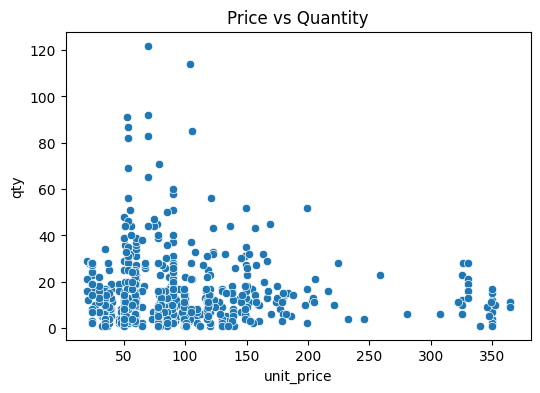

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="unit_price", y="qty")
plt.title("Price vs Quantity")
plt.show()